# Обучение моделей предсказания выкупа заказов

**Задача:** бинарная классификация — предсказать, выкупит ли клиент заказ (`buyout_flag`).

**Двухмодельная система:**
- **Повторные клиенты** (`contact_Число сделок >= 1`): buyout 97%+, LogReg на одном признаке (число прошлых сделок)
- **Новые клиенты** (первый заказ): buyout ~32%, LogReg на ~25 признаках с feature engineering

При инференсе `BuyoutPredictor` автоматически определяет тип клиента и применяет нужную модель.

Данные подготовлены в `01_data_analysis.ipynb` и загружаются из `processed_data.pkl`.

Этот ноутбук:
1. Обучает модель повторных клиентов (single-feature LogReg)
2. Кодирует признаки для новых клиентов (one-hot + StandardScaler + target encoding)
3. Обучает модель новых клиентов с 5-fold CV
4. Анализирует важность признаков
5. Сохраняет артефакты в `model_weights.pkl`
6. Валидирует через `BuyoutPredictor` на held-out данных

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import joblib
import warnings
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve, roc_curve,
    average_precision_score, balanced_accuracy_score, matthews_corrcoef
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

GREEN = '#2ecc71'
RED = '#e74c3c'

## 1. Загрузка подготовленных данных

Данные были подготовлены в `01_data_analysis.ipynb`: очистка, feature engineering, гео-матчинг, разбиение на train/test/val отдельно для новых и повторных клиентов.

In [2]:
with open('processed_data.pkl', 'rb') as f:
    art = pickle.load(f)

new_train = art['new_train']
new_test = art['new_test']
new_val = art['new_val']
ret_train = art['ret_train']
ret_test = art['ret_test']
ret_val = art['ret_val']
train_df = art['train_df']
test_df = art['test_df']
val_df = art['val_df']

cat_cols = art['cat_cols']
num_cols = art['num_cols']
bin_cols = art['bin_cols']
geo_cols = art['geo_cols']
te_cat_cols = art['te_cat_cols']
all_feature_cols = art['all_feature_cols']
russia_cities = art['russia_cities']

print('=== Размеры выборок ===')
print(f'Новые клиенты:    train={len(new_train)}, test={len(new_test)}, val={len(new_val)}')
print(f'Повторные:        train={len(ret_train)}, test={len(ret_test)}, val={len(ret_val)}')
print(f'Объединённые:     train={len(train_df)}, test={len(test_df)}, val={len(val_df)}')
print(f'\nBuyout rates:')
print(f'  new_train: {new_train["buyout_flag"].mean():.4f}')
print(f'  ret_train: {ret_train["buyout_flag"].mean():.4f}')
print(f'\nПризнаки: {len(cat_cols)} cat + {len(num_cols)} num + {len(bin_cols)} bin + {len(geo_cols)} geo + {len(te_cat_cols)} te_cat = {len(all_feature_cols)}')

=== Размеры выборок ===
Новые клиенты:    train=2447, test=816, val=816
Повторные:        train=8332, test=2778, val=2777
Объединённые:     train=10779, test=3594, val=3593

Buyout rates:
  new_train: 0.3249
  ret_train: 0.9762

Признаки: 11 cat + 4 num + 4 bin + 2 geo + 5 te_cat = 26


## 2. Модель повторных клиентов

Повторные клиенты (`contact_Число сделок >= 1`) выкупают в 97%+ случаев. Для них достаточно модели на **одном признаке** — числе прошлых сделок.

Модель обучается на **всех данных** (train_df = new_train + ret_train), чтобы выучить контраст между 0 заказов (новые клиенты, низкий buyout) и >=1 заказов (повторные, высокий buyout). NaN в `contact_Число сделок` заменяется на 0.

Buyout rate по числу прошлых заказов:
             buyout_rate  count
deals_group                    
1                 0.9771  10196
2                 0.9672   1918
3                 0.9721    645
4                 0.9892    372
5                 0.9815    216
6+                0.9852    540

Общий buyout rate повторных: 0.9762


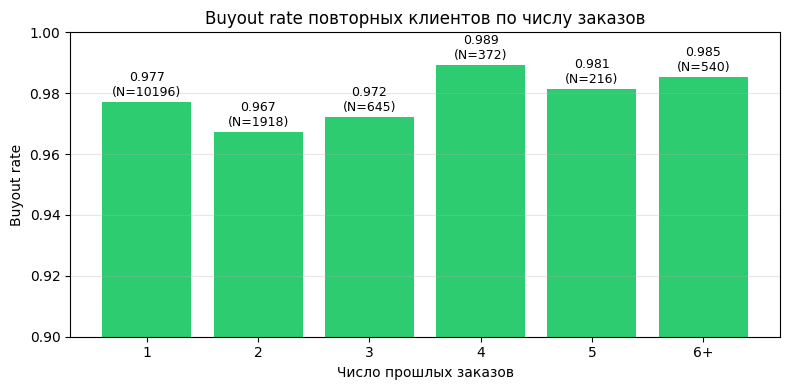

In [3]:
# Buyout rate по числу прошлых заказов
ret_all = pd.concat([ret_train, ret_test, ret_val])
ret_all['deals_group'] = ret_all['contact_Число сделок'].clip(upper=6).astype(int).astype(str)
ret_all.loc[ret_all['contact_Число сделок'] >= 6, 'deals_group'] = '6+'

stats = ret_all.groupby('deals_group')['buyout_flag'].agg(['mean', 'count']).sort_index()
stats.columns = ['buyout_rate', 'count']

print('Buyout rate по числу прошлых заказов:')
print(stats.to_string(float_format='%.4f'))
print(f'\nОбщий buyout rate повторных: {ret_all["buyout_flag"].mean():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [GREEN if r >= 0.95 else '#f39c12' for r in stats['buyout_rate']]
ax.bar(stats.index, stats['buyout_rate'], color=colors_bar)
ax.set_xlabel('Число прошлых заказов')
ax.set_ylabel('Buyout rate')
ax.set_title('Buyout rate повторных клиентов по числу заказов')
ax.set_ylim(0.9, 1.0)
ax.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(stats.iterrows()):
    ax.text(i, row['buyout_rate'] + 0.002, f'{row["buyout_rate"]:.3f}\n(N={int(row["count"])})',
            ha='center', fontsize=9)
plt.tight_layout(); plt.show()

In [4]:
FEAT_RET = 'contact_Число сделок'

# NaN → 0 (новые клиенты = 0 заказов)
train_df_1f = train_df.copy()
test_df_1f = test_df.copy()
train_df_1f[FEAT_RET] = train_df_1f[FEAT_RET].fillna(0)
test_df_1f[FEAT_RET] = test_df_1f[FEAT_RET].fillna(0)

X_1f_train = train_df_1f[[FEAT_RET]].values
y_1f_train = train_df_1f['buyout_flag'].values
X_1f_test = test_df_1f[[FEAT_RET]].values
y_1f_test = test_df_1f['buyout_flag'].values

scaler_ret = StandardScaler()
X_1f_train_sc = scaler_ret.fit_transform(X_1f_train)
X_1f_test_sc = scaler_ret.transform(X_1f_test)

model_ret = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_ret.fit(X_1f_train_sc, y_1f_train)

# Метрики на повторных клиентах из test
X_ret_test_sc = scaler_ret.transform(ret_test[[FEAT_RET]].values)
p_ret_test = model_ret.predict_proba(X_ret_test_sc)[:, 1]
y_ret_pred = (p_ret_test >= 0.5).astype(int)
y_ret_test_vals = ret_test['buyout_flag'].values

print('=' * 50)
print('Модель повторных клиентов (single-feature LogReg)')
print('=' * 50)
print(f'  Коэффициент: {model_ret.coef_[0][0]:.4f}')
print(f'  Intercept:   {model_ret.intercept_[0]:.4f}')
print(f'  Odds Ratio:  {np.exp(model_ret.coef_[0][0]):.2f}')
print()
print('  Метрики на повторных клиентах (test):')
print(f'    Accuracy:  {accuracy_score(y_ret_test_vals, y_ret_pred):.4f}')
print(f'    F1:        {f1_score(y_ret_test_vals, y_ret_pred):.4f}')
print(f'    ROC-AUC:   {roc_auc_score(y_ret_test_vals, p_ret_test):.4f}')
print(f'    Precision: {precision_score(y_ret_test_vals, y_ret_pred):.4f}')
print(f'    Recall:    {recall_score(y_ret_test_vals, y_ret_pred):.4f}')
print('=' * 50)

Модель повторных клиентов (single-feature LogReg)
  Коэффициент: 5.3147
  Intercept:   2.2038
  Odds Ratio:  203.31

  Метрики на повторных клиентах (test):
    Accuracy:  0.9762
    F1:        0.9880
    ROC-AUC:   0.4643
    Precision: 0.9762
    Recall:    1.0000


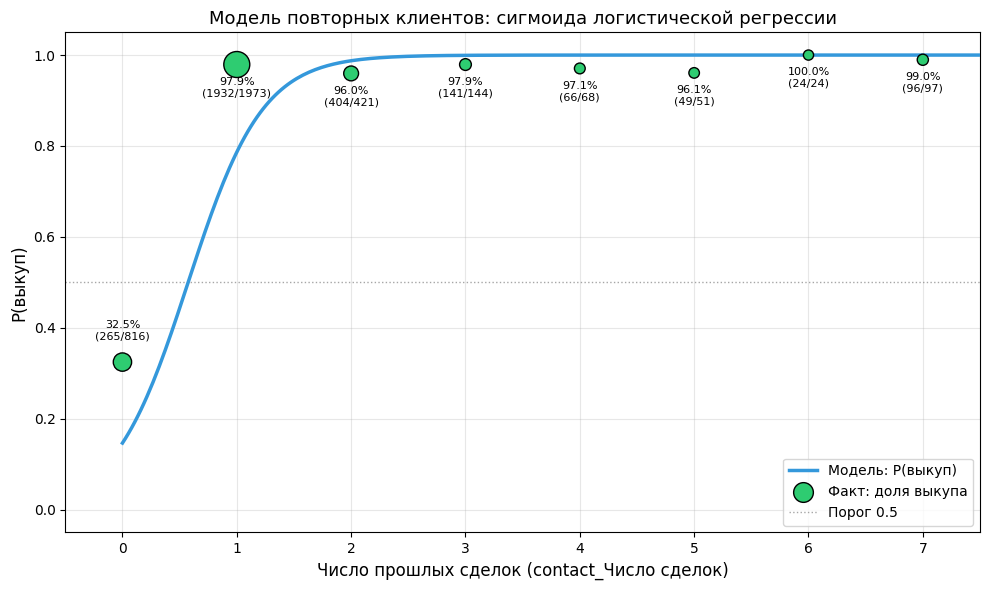


Интерпретация:
  Коэффициент = 5.31 → OR = 203
  Клиент с 0 заказов (новый) → низкая вероятность выкупа
  Клиент с 1+ заказов (повторный) → вероятность выкупа >95%
  Уже при 1 прошлом заказе модель уверенно предсказывает выкуп


In [5]:
# Сигмоида модели + фактические данные
# Показываем P(buyout) как функцию от числа прошлых сделок

# Гладкая сигмоида
x_range = np.linspace(0, 8, 300)
x_range_sc = scaler_ret.transform(x_range.reshape(-1, 1))
p_sigmoid = model_ret.predict_proba(x_range_sc)[:, 1]

# Фактические buyout rates по числу сделок (на test)
test_1f = test_df.copy()
test_1f[FEAT_RET] = test_1f[FEAT_RET].fillna(0)
test_1f['deals_int'] = test_1f[FEAT_RET].clip(upper=7).astype(int)

actual_stats = test_1f.groupby('deals_int')['buyout_flag'].agg(['mean', 'sum', 'count'])
actual_stats.columns = ['buyout_rate', 'n_buyout', 'n_total']
actual_stats['n_cancel'] = actual_stats['n_total'] - actual_stats['n_buyout']

fig, ax = plt.subplots(figsize=(10, 6))

# Сигмоида
ax.plot(x_range, p_sigmoid, color='#3498db', lw=2.5, label='Модель: P(выкуп)', zorder=3)

# Фактические точки — размер пропорционален количеству наблюдений
sizes = (actual_stats['n_total'] / actual_stats['n_total'].max()) * 300 + 50
ax.scatter(actual_stats.index, actual_stats['buyout_rate'],
           s=sizes, color=GREEN, edgecolor='black', linewidth=1,
           zorder=4, label='Факт: доля выкупа')

# Аннотации: buyout_rate и (выкуплено/всего)
for deals, row in actual_stats.iterrows():
    offset_y = -0.07 if row['buyout_rate'] > 0.5 else 0.05
    ax.annotate(f"{row['buyout_rate']:.1%}\n({int(row['n_buyout'])}/{int(row['n_total'])})",
                xy=(deals, row['buyout_rate']),
                xytext=(deals, row['buyout_rate'] + offset_y),
                ha='center', fontsize=8)

# Порог 0.5
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Порог 0.5')

ax.set_xlabel('Число прошлых сделок (contact_Число сделок)', fontsize=12)
ax.set_ylabel('P(выкуп)', fontsize=12)
ax.set_title('Модель повторных клиентов: сигмоида логистической регрессии', fontsize=13)
ax.set_xlim(-0.5, 7.5)
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(range(8))
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='both', alpha=0.3)

plt.tight_layout(); plt.show()

print("\nИнтерпретация:")
print(f"  Коэффициент = {model_ret.coef_[0][0]:.2f} → OR = {np.exp(model_ret.coef_[0][0]):.0f}")
print("  Клиент с 0 заказов (новый) → низкая вероятность выкупа")
print("  Клиент с 1+ заказов (повторный) → вероятность выкупа >95%")
print("  Уже при 1 прошлом заказе модель уверенно предсказывает выкуп")

---

## 3. Кодирование признаков для новых клиентов

Для модели новых клиентов применяем следующее кодирование:
- **One-hot encoding** для категориальных признаков с low/medium cardinality
- **StandardScaler** для числовых признаков
- **Passthrough** для бинарных признаков
- **K-fold smoothed target encoding** для географических и высококардинальных признаков (предотвращает утечку данных)

Target encoding со сглаживанием: `te = (count * mean + alpha * global_mean) / (count + alpha)`, alpha=10. Редкие категории подтягиваются к среднему.

In [6]:
TE_ALPHA = 10

def kfold_target_encoding(X, y, col, n_splits=5, alpha=TE_ALPHA, random_state=42):
    """Out-of-fold target encoding с additive smoothing."""
    global_mean = float(y.mean())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    te = np.full(len(X), global_mean)
    for train_idx, val_idx in kf.split(X):
        stats = X.iloc[train_idx].join(y.iloc[train_idx].rename('target')).groupby(col)['target'].agg(['mean', 'count'])
        stats['te'] = (stats['mean'] * stats['count'] + global_mean * alpha) / (stats['count'] + alpha)
        te[val_idx] = X.iloc[val_idx][col].map(stats['te']).fillna(global_mean).values
    return te


def encode_fold(X_tr, y_tr, X_va):
    """Полный пайплайн кодирования для одной пары train/val."""
    parts_tr, parts_va = [], []

    # One-hot
    c_tr = pd.get_dummies(X_tr[cat_cols], drop_first=True)
    c_va = pd.get_dummies(X_va[cat_cols], drop_first=True)
    c_tr, c_va = c_tr.align(c_va, join='left', axis=1, fill_value=0)
    parts_tr.append(c_tr); parts_va.append(c_va)

    # StandardScaler
    sc = StandardScaler().fit(X_tr[num_cols])
    parts_tr.append(pd.DataFrame(sc.transform(X_tr[num_cols]), columns=num_cols, index=X_tr.index))
    parts_va.append(pd.DataFrame(sc.transform(X_va[num_cols]), columns=num_cols, index=X_va.index))

    # Бинарные (без преобразования)
    parts_tr.append(X_tr[bin_cols].reset_index(drop=True).set_index(X_tr.index))
    parts_va.append(X_va[bin_cols].reset_index(drop=True).set_index(X_va.index))

    # Target encoding
    gm = float(y_tr.mean())
    for col_te in geo_cols + te_cat_cols:
        te_name = col_te + '_te'
        te_tr = kfold_target_encoding(X_tr, y_tr, col_te)
        parts_tr.append(pd.DataFrame({te_name: te_tr}, index=X_tr.index))
        stats = X_tr.join(y_tr.rename('target')).groupby(col_te)['target'].agg(['mean', 'count'])
        te_map = (stats['mean'] * stats['count'] + gm * TE_ALPHA) / (stats['count'] + TE_ALPHA)
        parts_va.append(pd.DataFrame({te_name: X_va[col_te].map(te_map).fillna(gm).values}, index=X_va.index))

    X_tr_enc = pd.concat(parts_tr, axis=1)
    X_va_enc = pd.concat(parts_va, axis=1).reindex(columns=X_tr_enc.columns, fill_value=0)
    return X_tr_enc, X_va_enc, sc


# Подготовка X/y
X_new_train = new_train[all_feature_cols].copy()
y_new_train = new_train['buyout_flag'].copy()
X_new_test = new_test[all_feature_cols].copy()
y_new_test = new_test['buyout_flag'].copy()

print(f'X_new_train: {X_new_train.shape}')
print(f'X_new_test:  {X_new_test.shape}')
print('Encoding functions defined')

X_new_train: (2447, 26)
X_new_test:  (816, 26)
Encoding functions defined


## 4. Кросс-валидация (5-fold)

Оцениваем качество модели на 5-fold стратифицированной кросс-валидации. Это даёт устойчивую оценку метрик и позволяет увидеть разброс.

In [7]:
cv = defaultdict(list)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, va_idx in skf.split(X_new_train, y_new_train):
    X_tr, X_va = X_new_train.iloc[tr_idx], X_new_train.iloc[va_idx]
    y_tr, y_va = y_new_train.iloc[tr_idx], y_new_train.iloc[va_idx]

    X_tr_enc, X_va_enc, _ = encode_fold(X_tr, y_tr, X_va)
    lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
    lr.fit(X_tr_enc, y_tr)

    proba = lr.predict_proba(X_va_enc)[:, 1]
    y_pred = (proba >= 0.5).astype(int)

    cv['accuracy'].append(accuracy_score(y_va, y_pred))
    cv['precision'].append(precision_score(y_va, y_pred))
    cv['recall'].append(recall_score(y_va, y_pred))
    cv['f1'].append(f1_score(y_va, y_pred))
    cv['roc_auc'].append(roc_auc_score(y_va, proba))
    cv['balanced_acc'].append(balanced_accuracy_score(y_va, y_pred))
    cv['mcc'].append(matthews_corrcoef(y_va, y_pred))

print('=' * 60)
print('5-Fold CV — Новые клиенты — LogReg (balanced)')
print('=' * 60)
for m, vals in cv.items():
    print(f'  {m:15s}: {np.mean(vals):.4f} \u00b1 {np.std(vals):.4f}')
print('=' * 60)

5-Fold CV — Новые клиенты — LogReg (balanced)
  accuracy       : 0.8124 ± 0.0169
  precision      : 0.6867 ± 0.0332
  recall         : 0.7849 ± 0.0363
  f1             : 0.7313 ± 0.0180
  roc_auc        : 0.8750 ± 0.0150
  balanced_acc   : 0.8053 ± 0.0141
  mcc            : 0.5929 ± 0.0285


## 5. Финальная модель новых клиентов

Обучаем финальную модель на полном `new_train` и оцениваем на `new_test`.

In [8]:
X_train_enc, X_test_enc, scaler_new = encode_fold(X_new_train, y_new_train, X_new_test)

model_new = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
model_new.fit(X_train_enc, y_new_train)

p_new_test = model_new.predict_proba(X_test_enc)[:, 1]
y_new_pred = (p_new_test >= 0.5).astype(int)

print('=' * 60)
print('Модель новых клиентов — TEST')
print('=' * 60)
print(f'  Accuracy:          {accuracy_score(y_new_test, y_new_pred):.4f}')
print(f'  Balanced Accuracy: {balanced_accuracy_score(y_new_test, y_new_pred):.4f}')
print(f'  Precision:         {precision_score(y_new_test, y_new_pred):.4f}')
print(f'  Recall:            {recall_score(y_new_test, y_new_pred):.4f}')
print(f'  F1:                {f1_score(y_new_test, y_new_pred):.4f}')
print(f'  ROC-AUC:           {roc_auc_score(y_new_test, p_new_test):.4f}')
print(f'  MCC:               {matthews_corrcoef(y_new_test, y_new_pred):.4f}')
print('=' * 60)
print()
print(classification_report(y_new_test, y_new_pred, target_names=['Отказ', 'Выкуп']))

Модель новых клиентов — TEST
  Accuracy:          0.8150
  Balanced Accuracy: 0.8101
  Precision:         0.6851
  Recall:            0.7962
  F1:                0.7365
  ROC-AUC:           0.8739
  MCC:               0.5991

              precision    recall  f1-score   support

       Отказ       0.89      0.82      0.86       551
       Выкуп       0.69      0.80      0.74       265

    accuracy                           0.81       816
   macro avg       0.79      0.81      0.80       816
weighted avg       0.83      0.81      0.82       816



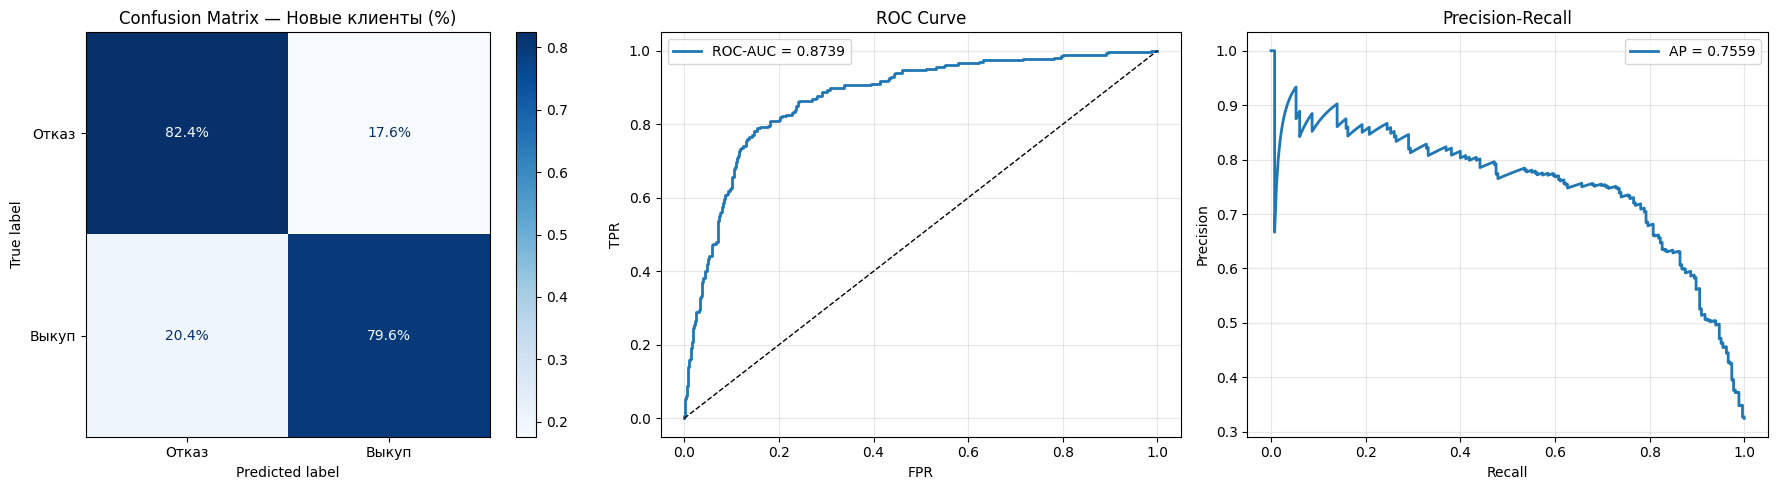

In [9]:
# Confusion Matrix (%) + ROC + PR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix в процентах
ConfusionMatrixDisplay.from_predictions(
    y_new_test, y_new_pred, display_labels=['Отказ', 'Выкуп'],
    normalize='true', values_format='.1%', ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Новые клиенты (%)')

# ROC
fpr, tpr, _ = roc_curve(y_new_test, p_new_test)
axes[1].plot(fpr, tpr, lw=2, label=f'ROC-AUC = {roc_auc_score(y_new_test, p_new_test):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Precision-Recall
prec_c, rec_c, _ = precision_recall_curve(y_new_test, p_new_test)
axes[2].plot(rec_c, prec_c, lw=2, label=f'AP = {average_precision_score(y_new_test, p_new_test):.4f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

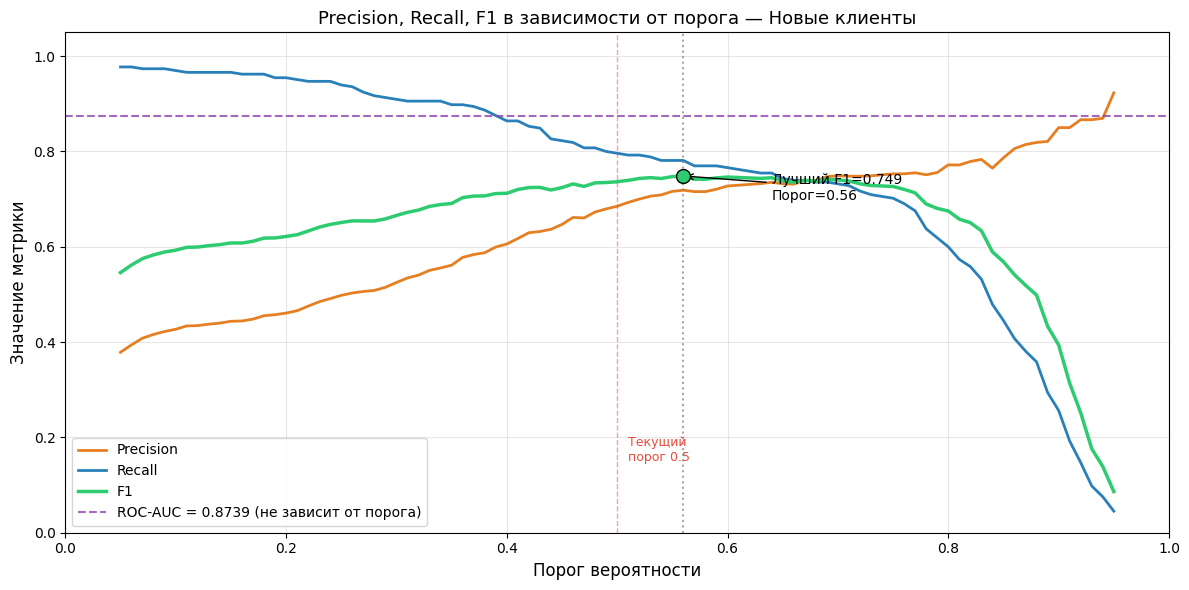

   Порог  Precision   Recall       F1
--------------------------------------
    0.30     0.5251   0.9094   0.6657
    0.40     0.6058   0.8642   0.7123
    0.56     0.7188   0.7811   0.7486 ← F1 max
    0.50     0.6851   0.7962   0.7365 ← текущий
    0.60     0.7276   0.7660   0.7463
    0.70     0.7490   0.7321   0.7405


In [10]:
# Анализ метрик в зависимости от порога вероятности
thresholds = np.arange(0.05, 0.96, 0.01)
metrics_by_t = {'threshold': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}

roc_auc_val = roc_auc_score(y_new_test, p_new_test)

for t in thresholds:
    y_t = (p_new_test >= t).astype(int)
    if y_t.sum() == 0 or y_t.sum() == len(y_t):
        continue
    metrics_by_t['threshold'].append(t)
    metrics_by_t['precision'].append(precision_score(y_new_test, y_t, zero_division=0))
    metrics_by_t['recall'].append(recall_score(y_new_test, y_t, zero_division=0))
    metrics_by_t['f1'].append(f1_score(y_new_test, y_t, zero_division=0))
    metrics_by_t['roc_auc'].append(roc_auc_val)  # ROC-AUC не зависит от порога

mt = pd.DataFrame(metrics_by_t)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(mt['threshold'], mt['precision'], color='#e67e22', lw=2, label='Precision')
ax.plot(mt['threshold'], mt['recall'], color='#2980b9', lw=2, label='Recall')
ax.plot(mt['threshold'], mt['f1'], color=GREEN, lw=2.5, label='F1')
ax.axhline(roc_auc_val, color='#8e44ad', linestyle='--', lw=1.5, alpha=0.8,
           label=f'ROC-AUC = {roc_auc_val:.4f} (не зависит от порога)')

# Оптимальный F1
best_idx = mt['f1'].idxmax()
best_t = mt.loc[best_idx, 'threshold']
best_f1 = mt.loc[best_idx, 'f1']
best_prec = mt.loc[best_idx, 'precision']
best_rec = mt.loc[best_idx, 'recall']

ax.axvline(best_t, color='gray', linestyle=':', alpha=0.7)
ax.scatter([best_t], [best_f1], color=GREEN, s=100, zorder=5, edgecolor='black')
ax.annotate(f'Лучший F1={best_f1:.3f}\nПорог={best_t:.2f}',
            xy=(best_t, best_f1), xytext=(best_t + 0.08, best_f1 - 0.05),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

# Порог 0.5 (текущий)
ax.axvline(0.5, color=RED, linestyle='--', alpha=0.5, lw=1)
ax.text(0.51, 0.15, 'Текущий\nпорог 0.5', color=RED, fontsize=9)

ax.set_xlabel('Порог вероятности', fontsize=12)
ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Precision, Recall, F1 в зависимости от порога — Новые клиенты', fontsize=13)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Таблица ключевых порогов
key_thresholds = [0.3, 0.4, best_t, 0.5, 0.6, 0.7]
print(f"{'Порог':>8} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-' * 38)
for t in key_thresholds:
    row = mt.iloc[(mt['threshold'] - t).abs().argsort().iloc[0]]
    marker = ' ← F1 max' if abs(row['threshold'] - best_t) < 0.02 else ''
    marker = ' ← текущий' if abs(row['threshold'] - 0.5) < 0.02 and not marker else marker
    print(f"{row['threshold']:>8.2f} {row['precision']:>10.4f} {row['recall']:>8.4f} {row['f1']:>8.4f}{marker}")

### Рекомендация по выбору порога

Выбор порога зависит от бизнес-приоритетов:

- **Порог 0.3–0.4 (высокий Recall):** модель «ловит» максимум потенциальных отказников, но допускает больше ложных срабатываний. Подходит, если стоимость невыкупленного заказа (доставка + возврат) значительно превышает стоимость ложного отказа в отправке.

- **Порог 0.5 (баланс):** стандартный порог, оптимальный баланс precision/recall. Рекомендуется как отправная точка.

- **Порог 0.6–0.7 (высокий Precision):** модель предсказывает отказ только когда уверена. Подходит, если важнее не потерять реального покупателя (не заблокировать заказ, который был бы выкуплен).

**Для интернет-магазина с наложенным платежом** рекомендуется порог в диапазоне **0.4–0.5**: стоимость невыкупа (доставка в обе стороны + упаковка + время) обычно выше, чем упущенная прибыль от одного ложно заблокированного заказа. При этом модель может не блокировать заказ, а сигнализировать менеджеру о рисковых заказах для дополнительной проверки (звонок клиенту для подтверждения).

## 6. Важность признаков

Для логистической регрессии коэффициент показывает направление и силу влияния признака:
- **Положительный коэффициент** (зелёный) — увеличивает вероятность выкупа
- **Отрицательный коэффициент** (красный) — снижает вероятность выкупа

Odds Ratio = exp(coef): во сколько раз изменяются шансы выкупа при увеличении признака на 1 (для числовых — на 1 std после масштабирования).

Encoded-признаков: 72

Топ-25 по |коэффициенту|:
                                            feature    coef  abs_coef  odds_ratio
                            lead_Служба доставки_te  4.8339    4.8339    125.6993
                           lead_pipeline_id_6892030 -2.1419    2.1419      0.1174
                                     price_bin_25k+ -1.1545    1.1545      0.3152
lead_Тариф Доставки_Экономичная посылка склад-склад -1.0093    1.0093      0.3645
                      lead_Вид оплаты_Оплата онлайн  0.9293    0.9293      2.5327
                    lead_Вид оплаты_Оплата на карту  0.9154    0.9154      2.4977
                           lead_pipeline_id_8182978 -0.8540    0.8540      0.4257
                           lead_pipeline_id_9222114  0.8537    0.8537      2.3484
                        lead_responsible_user_id_te  0.7594    0.7594      2.1369
                      lead_Модель телефона_Смартфон -0.7499    0.7499      0.4724
                                     sale_quarter

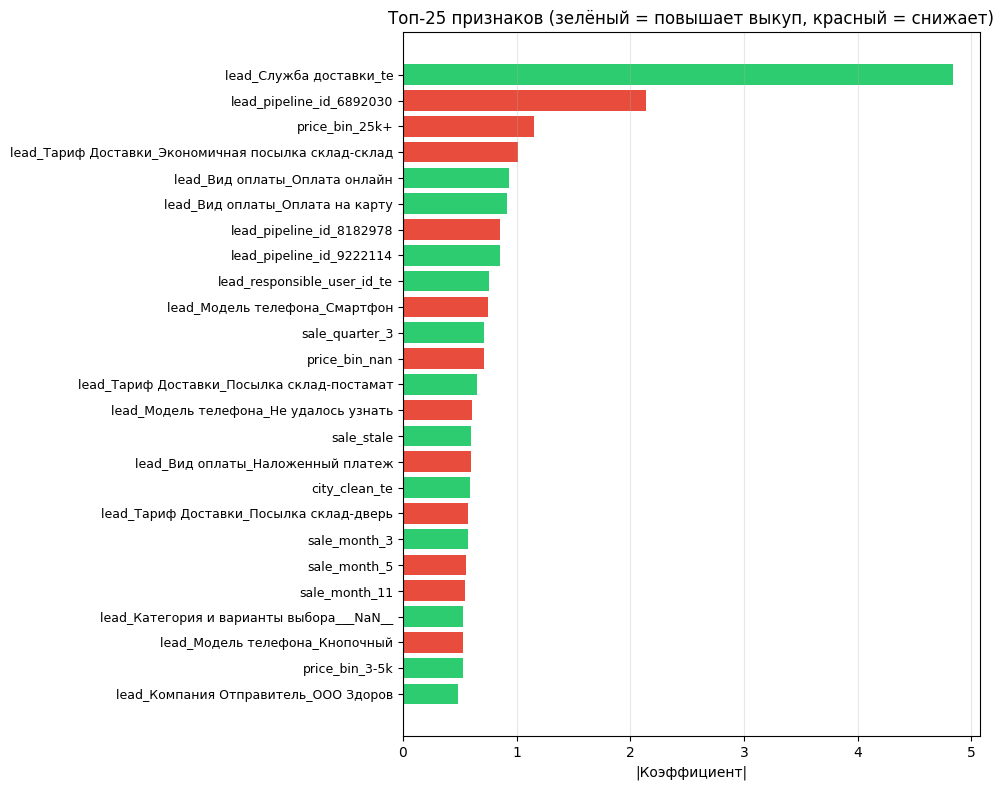

In [11]:
feat_imp = pd.DataFrame({
    'feature': X_train_enc.columns,
    'coef': model_new.coef_[0],
    'abs_coef': np.abs(model_new.coef_[0]),
    'odds_ratio': np.exp(model_new.coef_[0]),
}).sort_values('abs_coef', ascending=False)

print(f'Encoded-признаков: {len(feat_imp)}')
print(f'\nТоп-25 по |коэффициенту|:')
print(feat_imp.head(25).to_string(index=False, float_format='%.4f'))

# Bar chart
top25 = feat_imp.head(25).iloc[::-1]
colors = [GREEN if c > 0 else RED for c in top25['coef']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top25)), top25['abs_coef'].values, color=colors)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25['feature'].values, fontsize=9)
ax.set_xlabel('|Коэффициент|')
ax.set_title('Топ-25 признаков (зелёный = повышает выкуп, красный = снижает)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

Grouped Importance (по исходным признакам):
                                  sum_abs_coef  n_features
group                                                     
lead_Служба доставки                    4.8339           1
sale_month                              4.1457          11
lead_pipeline_id                        3.8495           3
lead_Тариф Доставки                     3.2798           9
price_bin                               2.8609           6
lead_Вид оплаты                         2.5243           4
lead_Модель телефона                    1.8807           3
lead_Категория и варианты выбора        1.4950           5
sale_quarter                            1.2446           3
lead_Квалификация лида                  1.2245           5
sale_weekday                            0.7626           6
lead_responsible_user_id                0.7594           1
lead_Компания Отправитель               0.6525           2
sale_stale                              0.6001           1
city_clean  

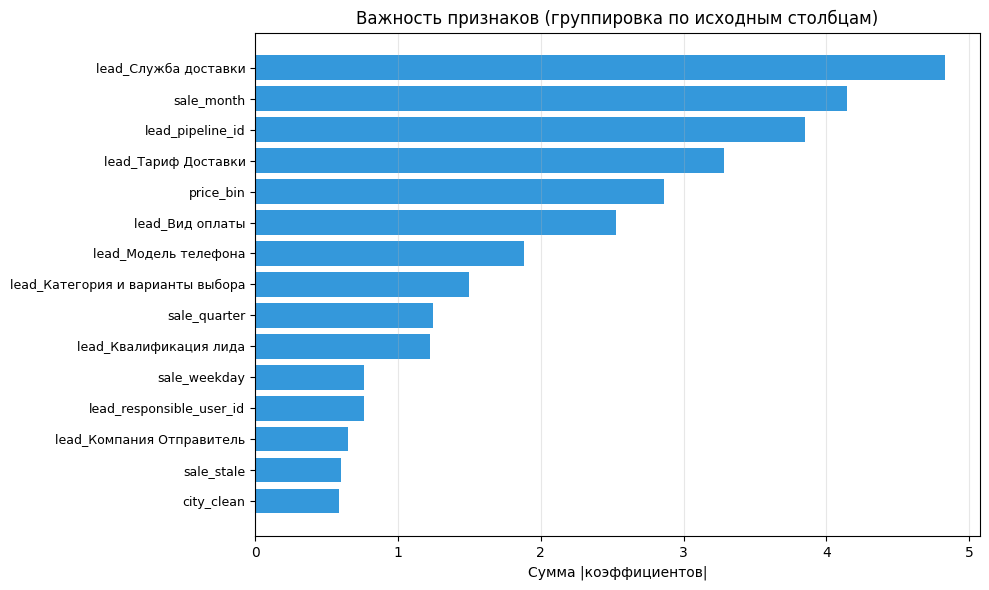

In [12]:
# Группировка важности по исходным признакам
def get_group(col_name):
    if col_name in bin_cols or col_name in num_cols:
        return col_name
    for tc in geo_cols + te_cat_cols:
        if col_name == tc + '_te':
            return tc
    for cat in sorted(cat_cols, key=len, reverse=True):
        if col_name.startswith(cat + '_'):
            return cat
    return col_name

feat_imp['group'] = feat_imp['feature'].apply(get_group)

grouped = feat_imp.groupby('group').agg(
    sum_abs_coef=('abs_coef', 'sum'),
    n_features=('feature', 'count'),
).sort_values('sum_abs_coef', ascending=False)

print('Grouped Importance (по исходным признакам):')
print(grouped.to_string(float_format='%.4f'))

# Bar chart grouped
top15g = grouped.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top15g)), top15g['sum_abs_coef'].values, color='#3498db')
ax.set_yticks(range(len(top15g)))
ax.set_yticklabels(top15g.index, fontsize=9)
ax.set_xlabel('Сумма |коэффициентов|')
ax.set_title('Важность признаков (группировка по исходным столбцам)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Сохранение артефактов модели

Все веса, скейлеры, маппинги target encoding и справочник городов сохраняются в единый файл `model_weights.pkl`. Класс `BuyoutPredictor` из `model.py` загружает этот файл для инференса.

In [13]:
# TE-маппинги из полного new_train
te_maps = {}
global_mean = float(y_new_train.mean())

for col_te in geo_cols + te_cat_cols:
    stats = X_new_train.join(y_new_train.rename('target')).groupby(col_te)['target'].agg(['mean', 'count'])
    te_map = (stats['mean'] * stats['count'] + global_mean * TE_ALPHA) / (stats['count'] + TE_ALPHA)
    te_maps[col_te] = te_map.to_dict()

# One-hot столбцы
onehot_part = pd.get_dummies(X_new_train[cat_cols], drop_first=True)
onehot_columns = onehot_part.columns.tolist()

# Маппинг количества сделок менеджера
manager_deal_count_map = new_train.groupby('lead_responsible_user_id').size().to_dict()
manager_deal_count_default = int(np.median(list(manager_deal_count_map.values())))

weights = {
    'model_new': model_new,
    'model_returning': model_ret,
    'scaler_new': scaler_new,
    'scaler_returning': scaler_ret,
    'onehot_columns': onehot_columns,
    'te_maps': te_maps,
    'global_mean': global_mean,
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'bin_cols': bin_cols,
    'geo_cols': geo_cols,
    'te_cat_cols': te_cat_cols,
    'russia_cities': russia_cities,
    'threshold': 0.5,
    'te_alpha': TE_ALPHA,
    'manager_deal_count_map': manager_deal_count_map,
    'manager_deal_count_default': manager_deal_count_default,
}

joblib.dump(weights, 'model_weights.pkl')

size_kb = os.path.getsize('model_weights.pkl') / 1024
print(f'Сохранено model_weights.pkl ({size_kb:.0f} KB)')
print(f'  Модель новых:     {len(onehot_columns)} one-hot + {len(num_cols)} num + {len(bin_cols)} bin + {len(geo_cols)+len(te_cat_cols)} TE')
print(f'  Модель повторных: 1 признак (contact_Число сделок)')
print(f'  Городов:          {len(russia_cities)}')
print(f'  Менеджеров:       {len(manager_deal_count_map)}')

Сохранено model_weights.pkl (99 KB)
  Модель новых:     57 one-hot + 4 num + 4 bin + 7 TE
  Модель повторных: 1 признак (contact_Число сделок)
  Городов:          1109
  Менеджеров:       26


## 8. Финальная валидация на held-out данных

Загружаем `BuyoutPredictor` из `model.py` и предсказываем на val-датасете, который **не использовался** ни при обучении, ни при подборе порога. Это честная оценка качества на «новых» данных.

In [14]:
from model import BuyoutPredictor

predictor = BuyoutPredictor('model_weights.pkl')

y_val = val_df['buyout_flag'].values
y_val_pred = predictor.predict(val_df)
y_val_proba = predictor.predict_proba(val_df)

print('=' * 60)
print('ФИНАЛЬНАЯ ВАЛИДАЦИЯ — полный val-датасет')
print('=' * 60)
print(f'  Строк:     {len(val_df)}')
print(f'  Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}')
print(f'  F1:        {f1_score(y_val, y_val_pred):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_val, y_val_proba):.4f}')
print(f'  Precision: {precision_score(y_val, y_val_pred):.4f}')
print(f'  Recall:    {recall_score(y_val, y_val_pred):.4f}')
print(f'  MCC:       {matthews_corrcoef(y_val, y_val_pred):.4f}')
print('=' * 60)

# Разбивка по типу клиента
is_new_val = val_df['contact_Число сделок'].isna() | (val_df['contact_Число сделок'] < 1)

for label, mask in [('Новые клиенты', is_new_val), ('Повторные клиенты', ~is_new_val)]:
    idx = mask.values
    if idx.sum() == 0:
        continue
    y_sub = y_val[idx]
    p_sub = y_val_pred[idx]
    pr_sub = y_val_proba[idx]
    print(f'\n  {label} (N={idx.sum()}):')
    print(f'    Accuracy:  {accuracy_score(y_sub, p_sub):.4f}')
    print(f'    F1:        {f1_score(y_sub, p_sub):.4f}')
    print(f'    ROC-AUC:   {roc_auc_score(y_sub, pr_sub):.4f}')
    print(f'    Precision: {precision_score(y_sub, p_sub):.4f}')
    print(f'    Recall:    {recall_score(y_sub, p_sub):.4f}')

ФИНАЛЬНАЯ ВАЛИДАЦИЯ — полный val-датасет
  Строк:     3593
  Accuracy:  0.9365
  F1:        0.9622
  ROC-AUC:   0.8886
  Precision: 0.9493
  Recall:    0.9755
  MCC:       0.7673

  Новые клиенты (N=816):
    Accuracy:  0.8015
    F1:        0.7033
    ROC-AUC:   0.8586
    Precision: 0.6833
    Recall:    0.7245

  Повторные клиенты (N=2777):
    Accuracy:  0.9762
    F1:        0.9880
    ROC-AUC:   0.5000
    Precision: 0.9762
    Recall:    1.0000


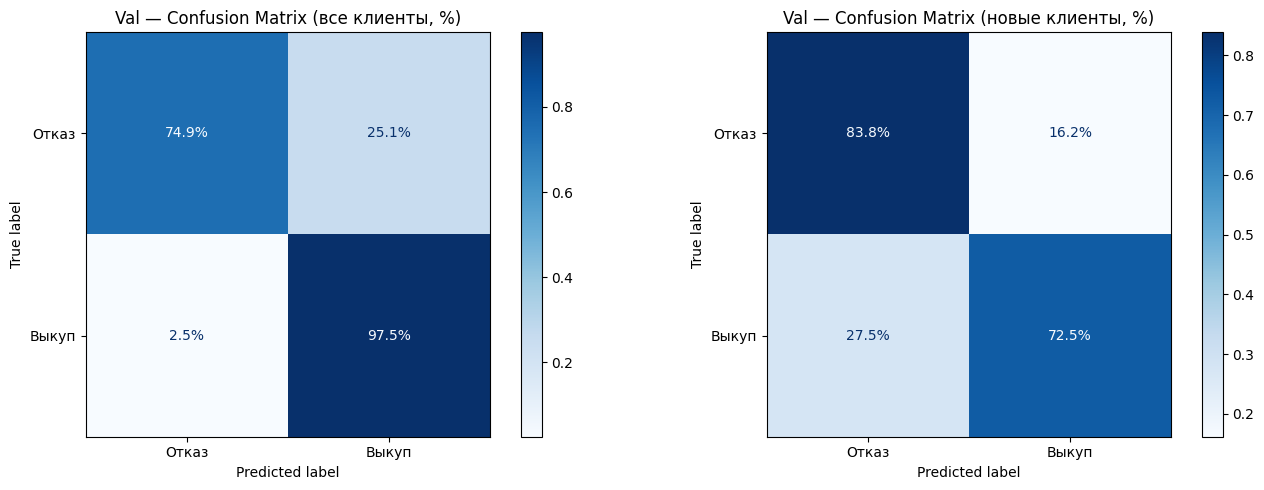


Валидация завершена.


In [15]:
# Confusion matrices на val — в процентах
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred, display_labels=['Отказ', 'Выкуп'],
    normalize='true', values_format='.1%', ax=axes[0], cmap='Blues'
)
axes[0].set_title('Val — Confusion Matrix (все клиенты, %)')

# Только новые клиенты
y_new_val = y_val[is_new_val.values]
y_new_val_pred = y_val_pred[is_new_val.values]

ConfusionMatrixDisplay.from_predictions(
    y_new_val, y_new_val_pred, display_labels=['Отказ', 'Выкуп'],
    normalize='true', values_format='.1%', ax=axes[1], cmap='Blues'
)
axes[1].set_title('Val — Confusion Matrix (новые клиенты, %)')

plt.tight_layout(); plt.show()
print('\nВалидация завершена.')